# 15. 自适应Saliency遮蔽攻击对抗性训练

## 15.0 主要内容介绍

本实验实现基于Saliency（简单梯度）的**自适应遮蔽攻击**对抗性训练：

1. **Saliency遮蔽攻击**: 使用简单梯度计算像素重要性，选择最重要的区域进行遮蔽
2. **自适应遮蔽攻击 (Adaptive)**: 
   - 渐进式增加遮蔽区域数量(n=1..N)和遮蔽半径(r=1..R)
   - 逐样本早停：攻击成功即停止，使用最小遮蔽量
   - 保留数字的语义可辨识性
3. **对抗性训练**: 使用自适应遮蔽攻击生成对抗样本进行训练

### 与固定遮蔽攻击的区别
- **固定攻击**: 直接遮蔽top_k个最重要区域，可能破坏数字语义
- **自适应攻击**: 使用最小遮蔽量达成攻击，数字语义更清晰

### 与IntegratedGradients版本的区别
- Saliency使用简单梯度 `|∂F/∂x|`，计算更快
- IntegratedGradients需要积分近似，更精确但计算慢

## 15.1 导入相关模块

In [1]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import pandas as pd
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import logging
import copy
from tqdm import tqdm

from occlusion_attack import SaliencyOcclusionAttack, AdaptiveSaliencyOcclusionAttack
from pgd import LinfPGD
from loss import CWLoss
from models import LeNet5
from utils import load_mnist_test
import test
test_fn = test.test

logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)
formatter = logging.Formatter(fmt='%(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print(f'Device: {device}')

Device: cuda


d:\anaconda3\envs\adv-attack\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 15.2 Saliency遮蔽攻击演示

使用简单梯度计算每个像素对预测的重要性，然后遮蔽最重要的区域。

In [2]:
# 加载标准模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', map_location=device, weights_only=False)
std_lenet = LeNet5().to(device)
std_lenet.load_state_dict(std_state['net'])
std_lenet.eval()
print('标准LeNet5模型加载完成')

# 加载测试集
imgs, lbls = load_mnist_test()
print(f'测试集大小: {imgs.shape[0]}')

标准LeNet5模型加载完成
测试集大小: 10000


In [3]:
# 测试干净样本准确率
clean_acc, _ = test_fn(std_lenet, imgs, lbls, bs=250, mode='clean')
logger.info(f'标准模型 - 干净样本准确率: {clean_acc:.2f}%')

20260409 22:30:58 标准模型 - 干净样本准确率: 99.00%


### 15.2.1 固定遮蔽攻击测试

In [4]:
# 测试不同top_k参数
top_k_values = [3, 5, 9, 15]
fixed_results = {}

for top_k in top_k_values:
    attack = SaliencyOcclusionAttack(std_lenet, top_k=top_k, kernel_size=3, occlu_color=0.0)
    acc, preds = test_fn(nn.Sequential(attack, std_lenet), imgs, lbls, bs=250, mode='attack')
    fixed_results[top_k] = {'acc': acc, 'preds': preds}
    logger.info(f'Fixed遮蔽攻击 (top_k={top_k}): 准确率={acc:.2f}%')

20260409 22:31:13 Fixed遮蔽攻击 (top_k=3): 准确率=86.82%
20260409 22:31:28 Fixed遮蔽攻击 (top_k=5): 准确率=80.99%
20260409 22:31:59 Fixed遮蔽攻击 (top_k=9): 准确率=71.19%
20260409 22:32:53 Fixed遮蔽攻击 (top_k=15): 准确率=59.78%


### 15.2.2 自适应遮蔽攻击测试

In [5]:
# 测试不同N参数
N_values = [1, 3, 5, 7,9, 10,15]
adaptive_results = {}
R_test=1
for N in N_values:
    attack = AdaptiveSaliencyOcclusionAttack(std_lenet, N=N, R=R_test, c=0.0)
    acc, preds = test_fn(nn.Sequential(attack, std_lenet), imgs, lbls, bs=250, mode='attack')
    adaptive_results[N] = {'acc': acc, 'preds': preds}
    logger.info(f'Adaptive遮蔽攻击 (N={N}, R={R_test}): 准确率={acc:.2f}%')

20260409 22:33:15 Adaptive遮蔽攻击 (N=1, R=1): 准确率=94.21%
20260409 22:33:18 Adaptive遮蔽攻击 (N=3, R=1): 准确率=82.51%
20260409 22:33:24 Adaptive遮蔽攻击 (N=5, R=1): 准确率=71.66%
20260409 22:33:32 Adaptive遮蔽攻击 (N=7, R=1): 准确率=62.45%
20260409 22:33:42 Adaptive遮蔽攻击 (N=9, R=1): 准确率=54.85%
20260409 22:33:52 Adaptive遮蔽攻击 (N=10, R=1): 准确率=51.28%
20260409 22:34:07 Adaptive遮蔽攻击 (N=15, R=1): 准确率=37.85%


### 15.2.3 可视化攻击效果（含真实值和预测）

In [6]:
def imshow_with_pred(img, model, true_label, ax=None, title_prefix=''):
    """显示图像并标注真实标签和预测结果"""
    npimg = img.cpu().squeeze().numpy()
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(dim=1).item()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))
    
    ax.imshow(npimg, cmap='gray')
    correct_str = 'OK' if pred == true_label else 'X'
    ax.set_title(f'{title_prefix}\n真实:{true_label} 预测:{pred} {correct_str}', fontsize=10)
    ax.axis('off')
    return pred == true_label

# 选择展示的样本（每个数字一个）
sample_indices = []
shown = set()
for i in range(len(lbls)):
    label = int(lbls[i].item())
    if label not in shown:
        shown.add(label)
        sample_indices.append(i)
    if len(shown) == 10:
        break

print(f'展示样本索引: {sample_indices}')

展示样本索引: [0, 1, 2, 3, 4, 5, 9, 15, 16, 23]


In [ ]:
# 可视化固定遮蔽攻击效果
fig, axes = plt.subplots(10, 5, figsize=(15, 30))

for row, idx in enumerate(sample_indices):
    x = imgs[idx:idx+1].to(device)
    y = lbls[idx:idx+1].to(device)
    true_label = int(y.item())
    
    # 干净样本
    imshow_with_pred(x.squeeze(0), std_lenet, true_label, ax=axes[row, 0], title_prefix='干净样本')
    
    # 不同top_k的遮蔽攻击
    for col, top_k in enumerate(top_k_values):
        attack = SaliencyOcclusionAttack(std_lenet, top_k=top_k, kernel_size=3, occlu_color=0.0)
        x_adv = attack((x, y))
        imshow_with_pred(x_adv.squeeze(0), std_lenet, true_label, 
                        ax=axes[row, col+1], title_prefix=f'Fixed k={top_k}')

plt.tight_layout()
plt.savefig(f'./results_figures/saliency_fixed_attack_visualization_{N}_{R}.png', dpi=150, bbox_inches='tight')
plt.show()
print('固定遮蔽攻击可视化已保存')

In [ ]:
# 可视化自适应遮蔽攻击效果
fig, axes = plt.subplots(10, 5, figsize=(15, 30))

for row, idx in enumerate(sample_indices):
    x = imgs[idx:idx+1].to(device)
    y = lbls[idx:idx+1].to(device)
    true_label = int(y.item())
    
    # 干净样本
    imshow_with_pred(x.squeeze(0), std_lenet, true_label, ax=axes[row, 0], title_prefix='干净样本')
    
    # 不同N参数的自适应遮蔽攻击
    for col, N_val in enumerate([3, 5, 9, 15]):
        attack = AdaptiveSaliencyOcclusionAttack(std_lenet, N=N_val, R=3, c=0.0)
        x_adv = attack((x, y))
        imshow_with_pred(x_adv.squeeze(0), std_lenet, true_label, 
                        ax=axes[row, col+1], title_prefix=f'Adaptive N={N_val}')

plt.tight_layout()
plt.savefig(f'./results_figures/saliency_Adaptive_attack_visualization_R=3_{N}_{R}.png', dpi=150, bbox_inches='tight')
plt.show()
print('自适应遮蔽攻击可视化已保存')

In [ ]:
# 可视化自适应遮蔽攻击效果
fig, axes = plt.subplots(10, 5, figsize=(15, 30))

for row, idx in enumerate(sample_indices):
    x = imgs[idx:idx+1].to(device)
    y = lbls[idx:idx+1].to(device)
    true_label = int(y.item())
    
    # 干净样本
    imshow_with_pred(x.squeeze(0), std_lenet, true_label, ax=axes[row, 0], title_prefix='干净样本')
    
    # 不同N参数的自适应遮蔽攻击
    for col, N_val in enumerate([3, 5, 9, 15]):
        attack = AdaptiveSaliencyOcclusionAttack(std_lenet, N=N_val, R=1, c=0.0)
        x_adv = attack((x, y))
        imshow_with_pred(x_adv.squeeze(0), std_lenet, true_label, 
                        ax=axes[row, col+1], title_prefix=f'Adaptive N={N_val}')

plt.tight_layout()
plt.savefig(f'./results_figures/saliency_Adaptive_attack_visualization_R=1_{N}_{R}.png', dpi=150, bbox_inches='tight')
plt.show()
print('自适应遮蔽攻击可视化已保存')

## 15.3 基于自适应Saliency遮蔽攻击的对抗性训练

与固定遮蔽攻击对抗性训练不同，自适应遮蔽攻击：
1. 渐进式增加遮蔽区域数量和半径
2. 逐样本早停：一旦攻击成功（预测改变）即停止该样本的遮蔽
3. 使用最小遮蔽量，保留数字的语义可辨识性

In [15]:
# 超参数
EPOCH = 50
BATCH_SIZE = 256
LR = 0.001

# 自适应遮蔽攻击参数
N = 5              # 最大遮蔽区域数量
R = 1              # 最大遮蔽半径
C_COLOR = 0.0      # 黑色遮蔽

print(f'训练参数: EPOCH={EPOCH}, BATCH_SIZE={BATCH_SIZE}, LR={LR}')
print(f'自适应遮蔽参数: N={N}, R={R}, C_COLOR={C_COLOR}')

# 加载数据集
train_dataset = torchvision.datasets.MNIST(
    root="./data/", train=True, download=False, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(
    root="./data/", train=False, download=False, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print(f'训练集: {len(train_dataset)}, 测试集: {len(test_dataset)}')

训练参数: EPOCH=50, BATCH_SIZE=256, LR=0.001
自适应遮蔽参数: N=5, R=1, C_COLOR=0.0
训练集: 60000, 测试集: 10000


In [16]:
# 定义自适应Saliency遮蔽攻击对抗性训练模块
class AdaptiveSaliencyOcclusionAT(nn.Module):
    """基于自适应Saliency遮蔽攻击的对抗性训练
    
    与固定遮蔽攻击的区别：
    - 渐进式增加遮蔽区域数量(n=1..N)和遮蔽半径(r=1..R)
    - 逐样本早停：攻击成功即停止，使用最小遮蔽量
    """
    
    def __init__(self, model, N=5, R=3, c=0.0):
        super().__init__()
        self.model = model
        self.attack = AdaptiveSaliencyOcclusionAttack(model, N=N, R=R, c=c)
    
    def forward(self, x, y=None):
        if y is None:
            return self.model(x)
        
        # 生成对抗样本
        training = self.model.training
        self.model.eval()
        x_adv = self.attack((x, y))
        if training:
            self.model.train()
        
        return self.model(x_adv)

# 初始化模型
cnn = LeNet5().to(device)
cnn_at = AdaptiveSaliencyOcclusionAT(cnn, N=N, R=R, c=C_COLOR)

optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f'模型参数量: {num_params}')
print(f'使用自适应遮蔽攻击: N={N}, R={R}')

模型参数量: 61706
使用自适应遮蔽攻击: N=5, R=1


In [ ]:
# 训练循环
train_accs, train_losses = [], []
test_accs, test_losses = [], []
test_clean_accs = []
best_acc = 0
best_state = None

for epoch in range(EPOCH):
    # 训练
    cnn_at.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCH}'):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = cnn_at(inputs, labels)
        loss = loss_fn(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred = outputs.argmax(dim=1)
        train_correct += (pred == labels).sum().item()
        train_total += n
        train_loss += loss.item() * n
    
    train_acc = train_correct / train_total
    train_loss_avg = train_loss / train_total
    train_accs.append(train_acc)
    train_losses.append(train_loss_avg)
    
    # 测试（对抗样本）
    cnn_at.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    test_clean_correct = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            n = labels.size(0)
            inputs, labels = inputs.to(device), labels.to(device)
            
            # 干净样本测试
            pred_clean = cnn(inputs).argmax(dim=1)
            test_clean_correct += (pred_clean == labels).sum().item()
            
            # 对抗样本测试
            outputs = cnn_at(inputs, labels)
            loss = loss_fn(outputs, labels)
            pred = outputs.argmax(dim=1)
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.item() * n
    
    test_acc = test_correct / test_total
    test_loss_avg = test_loss / test_total
    test_clean_acc = test_clean_correct / test_total
    
    test_accs.append(test_acc)
    test_losses.append(test_loss_avg)
    test_clean_accs.append(test_clean_acc)
    
    logger.info(f'Epoch {epoch+1}: Train Loss={train_loss_avg:.4f}, Train Acc={100*train_acc:.2f}%, '
                f'Test(Robust)={100*test_acc:.2f}%, Test(Clean)={100*test_clean_acc:.2f}%')
    
    # 保存最佳模型
    if test_acc > best_acc:
        best_acc = test_acc
        best_state = copy.deepcopy(cnn.state_dict())

# 加载最佳模型
if best_state is not None:
    cnn.load_state_dict(best_state)
    print(f'加载最佳模型，鲁棒准确率: {100*best_acc:.2f}%')

20260409 23:11:34 Epoch 1: Train Loss=0.3469, Train Acc=86.02%, Test(Robust)=92.69%, Test(Clean)=96.00%
20260409 23:12:17 Epoch 2: Train Loss=0.1653, Train Acc=93.21%, Test(Robust)=94.24%, Test(Clean)=97.48%
20260409 23:13:00 Epoch 3: Train Loss=0.1355, Train Acc=94.17%, Test(Robust)=95.05%, Test(Clean)=97.76%
20260409 23:13:44 Epoch 4: Train Loss=0.1140, Train Acc=94.93%, Test(Robust)=95.20%, Test(Clean)=97.71%
20260409 23:14:27 Epoch 5: Train Loss=0.0983, Train Acc=95.66%, Test(Robust)=95.89%, Test(Clean)=98.60%


In [ ]:
# 保存模型
state = {
    'net': cnn.state_dict(),
    'epoch': EPOCH,
    'train_losses': train_losses,
    'train_accs': train_accs,
    'test_losses': test_losses,
    'test_accs': test_accs,
    'test_clean_accs': test_clean_accs,
    'params': {'N': N, 'R': R, 'c': C_COLOR}
}

save_dir = f'./save_model/{EPOCH}epoch'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f'mnist_lenet5_AdaptiveSaliencyOcclusionAT_{N}_{R}.pth')
torch.save(state, save_path)
print(f'模型已保存: {save_path}')

模型已保存: ./save_model/50epoch\mnist_lenet5_AdaptiveSaliencyOcclusionAT_5_3.pth


In [ ]:
# 绘制训练曲线
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = list(range(1, EPOCH+1))

# 准确率曲线
axes[0].plot(epochs, [100*a for a in train_accs], 'b-', label='Train(Robust)', linewidth=2)
axes[0].plot(epochs, [100*a for a in test_accs], 'r-', label='Test(Robust)', linewidth=2)
axes[0].plot(epochs, [100*a for a in test_clean_accs], 'g--', label='Test(Clean)', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Accuracy Curves', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 损失曲线
axes[1].plot(epochs, train_losses, 'b-', label='Train', linewidth=2)
axes[1].plot(epochs, test_losses, 'r-', label='Test', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Loss Curves', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 干净 vs 对抗准确率
axes[2].plot(epochs, [100*a for a in test_clean_accs], 'g-', label='Clean', linewidth=2)
axes[2].plot(epochs, [100*a for a in test_accs], 'm-', label='Adversarial', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Accuracy (%)', fontsize=12)
axes[2].set_title('Clean vs Adversarial Accuracy (Test)', fontsize=14)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'./results_figures/saliency_at_training_curves_{N}_{R}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'训练完成: 最终测试准确率 - 干净={100*test_clean_accs[-1]:.2f}%, 对抗={100*test_accs[-1]:.2f}%')

## 15.4 鲁棒性评测

对训练好的模型进行多角度评测，包括：
1. 不同参数的固定遮蔽攻击
2. 不同参数的自适应遮蔽攻击

In [ ]:
# 加载测试集
imgs, lbls = load_mnist_test()

# 干净样本准确率
cnn.eval()
clean_acc, clean_preds = test_fn(cnn, imgs, lbls, bs=250, mode='clean')
logger.info(f'Saliency-AT模型 - 干净样本准确率: {clean_acc:.2f}%')

20260404 20:16:47 Saliency-AT模型 - 干净样本准确率: 98.73%


### 15.4.1 自适应遮蔽攻击评测（不同N和R）

In [ ]:
# 测试不同N和R参数组合
N_test = [3, 5, 7, 10]
R_test = [2, 3, 4]
adaptive_eval_results = []

# 测试不同N（固定R=3）
for N_val in N_test:
    attack = AdaptiveSaliencyOcclusionAttack(cnn, N=N_val, R=3, c=0.0)
    acc, preds = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    adaptive_eval_results.append({
        'attack': 'Adaptive',
        'param': f'N={N_val},R=3',
        'N': N_val,
        'R': 3,
        'accuracy': acc
    })
    logger.info(f'Adaptive遮蔽攻击 (N={N_val}, R=3): {acc:.2f}%')

# 测试不同R（固定N=5）
for R_val in R_test:
    attack = AdaptiveSaliencyOcclusionAttack(cnn, N=5, R=R_val, c=0.0)
    acc, preds = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    adaptive_eval_results.append({
        'attack': 'Adaptive',
        'param': f'N=5,R={R_val}',
        'N': 5,
        'R': R_val,
        'accuracy': acc
    })
    logger.info(f'Adaptive遮蔽攻击 (N=5, R={R_val}): {acc:.2f}%')

20260404 20:16:58 Adaptive遮蔽攻击 (N=3, R=3): 95.97%
20260404 20:17:14 Adaptive遮蔽攻击 (N=5, R=3): 94.30%
20260404 20:17:35 Adaptive遮蔽攻击 (N=7, R=3): 92.44%
20260404 20:18:05 Adaptive遮蔽攻击 (N=10, R=3): 88.74%
20260404 20:18:16 Adaptive遮蔽攻击 (N=5, R=2): 96.41%
20260404 20:18:32 Adaptive遮蔽攻击 (N=5, R=3): 94.30%
20260404 20:18:52 Adaptive遮蔽攻击 (N=5, R=4): 88.11%


### 15.4.2 固定遮蔽攻击评测（不同top_k）

作为对比，也测试固定遮蔽攻击的效果。

In [ ]:
# 测试不同top_k（固定攻击，作为对比）
top_k_test = [3, 5, 7, 9, 12, 15]
fixed_eval_results = []

for top_k in top_k_test:
    attack = SaliencyOcclusionAttack(cnn, top_k=top_k, kernel_size=3, occlu_color=0.0)
    acc, preds = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    fixed_eval_results.append({
        'attack': 'Fixed',
        'param': f'top_k={top_k}',
        'top_k': top_k,
        'accuracy': acc
    })
    logger.info(f'Fixed遮蔽攻击 (top_k={top_k}): {acc:.2f}%')

20260404 20:19:00 Fixed遮蔽攻击 (top_k=3): 98.62%
20260404 20:19:15 Fixed遮蔽攻击 (top_k=5): 98.61%
20260404 20:19:38 Fixed遮蔽攻击 (top_k=7): 98.49%
20260404 20:20:10 Fixed遮蔽攻击 (top_k=9): 98.43%
20260404 20:20:56 Fixed遮蔽攻击 (top_k=12): 98.31%
20260404 20:21:55 Fixed遮蔽攻击 (top_k=15): 98.20%


### 15.4.3 不同遮蔽颜色评测

In [ ]:
# 测试不同遮蔽颜色（使用Adaptive攻击）
colors = [0.0, 0.5, 1.0]
color_names = ['黑色', '灰色', '白色']
color_eval_results = []

for c, name in zip(colors, color_names):
    attack = AdaptiveSaliencyOcclusionAttack(cnn, N=5, R=3, c=c)
    acc, preds = test_fn(nn.Sequential(attack, cnn), imgs, lbls, bs=250, mode='attack')
    color_eval_results.append({
        'attack': 'Adaptive',
        'param': f'color={name}',
        'accuracy': acc
    })
    logger.info(f'Adaptive遮蔽攻击 (颜色={name}): {acc:.2f}%')

20260404 20:22:11 Adaptive遮蔽攻击 (颜色=黑色): 94.30%
20260404 20:22:25 Adaptive遮蔽攻击 (颜色=灰色): 45.60%
20260404 20:22:40 Adaptive遮蔽攻击 (颜色=白色): 14.18%


In [ ]:
# 绘制参数敏感性图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Adaptive攻击 - N影响（固定R=3）
n_results = [r for r in adaptive_eval_results if r['R'] == 3]
N_vals = [r['N'] for r in n_results]
acc_vals = [r['accuracy'] for r in n_results]

axes[0].plot(N_vals, acc_vals, 'ro-', markersize=10, linewidth=2)
axes[0].axhline(y=clean_acc, color='g', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[0].set_xlabel('N (最大遮蔽区域数)', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Adaptive攻击: N参数影响 (R=3)', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Fixed攻击 - top_k影响（对比）
top_k_vals = [r['top_k'] for r in fixed_eval_results]
acc_vals_fixed = [r['accuracy'] for r in fixed_eval_results]

axes[1].plot(top_k_vals, acc_vals_fixed, 'bo-', markersize=10, linewidth=2)
axes[1].axhline(y=clean_acc, color='g', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[1].set_xlabel('top_k (遮蔽区域数量)', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Fixed攻击: top_k参数影响 (对比)', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'./results_figures/adaptive_saliency_at_param_sensitivity_{N}_{R}.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 绘制R参数和颜色影响
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R参数影响
r_results = [r for r in adaptive_eval_results if r['N'] == 5]
R_vals = [r['R'] for r in r_results]
acc_r = [r['accuracy'] for r in r_results]

axes[0].plot(R_vals, acc_r, 'go-', markersize=10, linewidth=2)
axes[0].axhline(y=clean_acc, color='b', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[0].set_xlabel('R (遮蔽半径)', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Adaptive攻击: R参数影响 (N=5)', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 遮蔽颜色影响
color_accs = [r['accuracy'] for r in color_eval_results]
bar_colors = ['black', 'gray', 'white']
edges = ['white', 'black', 'black']

bars = axes[1].bar(range(len(color_names)), color_accs, color=bar_colors, edgecolor=edges, linewidth=2)
axes[1].set_xticks(range(len(color_names)))
axes[1].set_xticklabels(color_names)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Adaptive攻击: 遮蔽颜色影响 (N=5, R=3)', fontsize=14)
axes[1].axhline(y=clean_acc, color='blue', linestyle='--', label=f'Clean: {clean_acc:.1f}%')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'./results_figures/adaptive_saliency_at_r_color_{N}_{R}.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 综合柱状图展示
fig, ax = plt.subplots(figsize=(14, 6))

# 准备数据
x_pos = np.arange(len(adaptive_eval_results) + len(fixed_eval_results))
acc_all = [r['accuracy'] for r in adaptive_eval_results] + [r['accuracy'] for r in fixed_eval_results]
labels = [r['param'] for r in adaptive_eval_results] + [r['param'] for r in fixed_eval_results]
colors_bar = ['coral'] * len(adaptive_eval_results) + ['steelblue'] * len(fixed_eval_results)

bars = ax.bar(x_pos, acc_all, color=colors_bar, alpha=0.8, edgecolor='black')
ax.axhline(y=clean_acc, color='green', linestyle='--', linewidth=2, label=f'Clean: {clean_acc:.1f}%')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=9, rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Adaptive-Saliency-AT模型: 不同攻击参数下的鲁棒性', fontsize=14)

# 添加图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='coral', label='Adaptive攻击'),
                   Patch(facecolor='steelblue', label='Fixed攻击'),
                   plt.Line2D([0], [0], color='green', linestyle='--', label=f'Clean: {clean_acc:.1f}%')]
ax.legend(handles=legend_elements, fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar, val in zip(bars, acc_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'./results_figures/adaptive_saliency_at_robustness_bar_{N}_{R}.png', dpi=150, bbox_inches='tight')
plt.show()

## 15.6 攻击效果可视化（含预测结果）

In [ ]:
# 加载标准模型
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth', map_location=device, weights_only=False)
std_model = LeNet5().to(device)
std_model.load_state_dict(std_state['net'])
std_model.eval()

# 对比评测
comparison_results = []

for model_name, model in [('Standard', std_model), ('Adaptive-Saliency-AT', cnn)]:
    model.eval()
    
    # 干净样本
    clean, _ = test_fn(model, imgs, lbls, bs=250, mode='clean')
    
    # Adaptive攻击 (N=5, R=3)
    attack_adaptive = AdaptiveSaliencyOcclusionAttack(model, N=5, R=3, c=0.0)
    adaptive_acc, _ = test_fn(nn.Sequential(attack_adaptive, model), imgs, lbls, bs=250, mode='attack')
    
    # Adaptive攻击 (N=10, R=3)
    attack_adaptive_10 = AdaptiveSaliencyOcclusionAttack(model, N=10, R=3, c=0.0)
    adaptive_acc_10, _ = test_fn(nn.Sequential(attack_adaptive_10, model), imgs, lbls, bs=250, mode='attack')
    
    # Fixed攻击 (对比)
    attack_fixed = SaliencyOcclusionAttack(model, top_k=9, kernel_size=3, occlu_color=0.0)
    fixed_acc, _ = test_fn(nn.Sequential(attack_fixed, model), imgs, lbls, bs=250, mode='attack')
    
    comparison_results.append({
        'Model': model_name,
        'Clean': round(clean, 2),
        'Adaptive(N=5,R=3)': round(adaptive_acc, 2),
        'Adaptive(N=10,R=3)': round(adaptive_acc_10, 2),
        'Fixed(k=9)': round(fixed_acc, 2)
    })

df_compare = pd.DataFrame(comparison_results)
print('\n========== 标准模型 vs Adaptive-Saliency-AT 对比 ==========')
print(df_compare.to_string(index=False))

NameError: name 'pd' is not defined

NameError: name 'comparison_results' is not defined

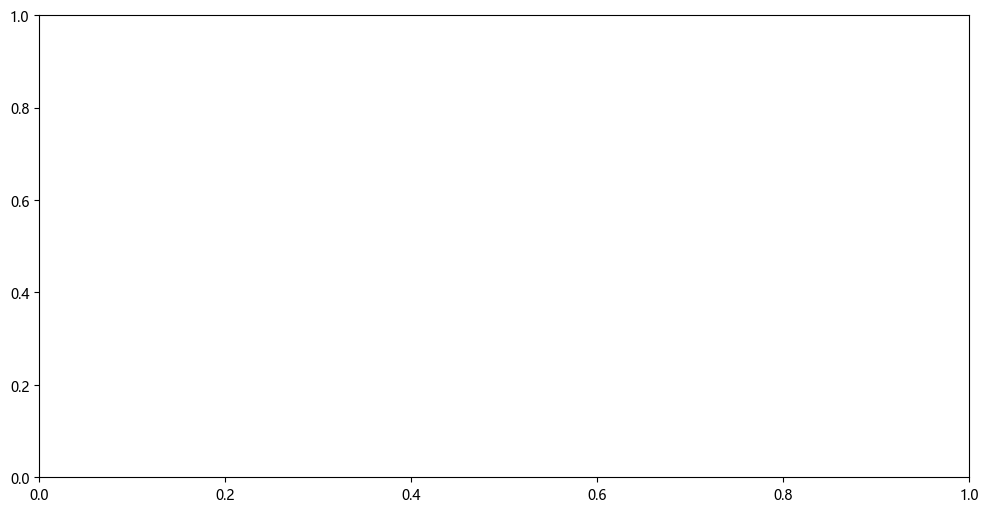

In [ ]:
# 绘制对比图
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(4)
width = 0.35

std_vals = [comparison_results[0]['Clean'], 
            comparison_results[0]['Adaptive(N=5,R=3)'],
            comparison_results[0]['Adaptive(N=10,R=3)'],
            comparison_results[0]['Fixed(k=9)']]
at_vals = [comparison_results[1]['Clean'], 
           comparison_results[1]['Adaptive(N=5,R=3)'],
           comparison_results[1]['Adaptive(N=10,R=3)'],
           comparison_results[1]['Fixed(k=9)']]

bars1 = ax.bar(x - width/2, std_vals, width, label='Standard', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, at_vals, width, label='Adaptive-Saliency-AT', color='coral', alpha=0.8)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('标准模型 vs Adaptive-Saliency-AT 鲁棒性对比', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Clean', 'Adaptive\n(N=5,R=3)', 'Adaptive\n(N=10,R=3)', 'Fixed\n(k=9)'])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar, val in zip(bars1, std_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=9)
for bar, val in zip(bars2, at_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'./results_figures/adaptive_saliency_at_comparison_{N}_{R}.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 保存所有评测结果
df_all = pd.DataFrame(adaptive_eval_results + fixed_eval_results)
df_all.to_csv('./results_figures/adaptive_saliency_at_evaluation_results.csv', index=False)

df_compare.to_csv('./results_figures/adaptive_saliency_at_comparison.csv', index=False)

print('评测结果已保存至:')
print('  - ./results_figures/adaptive_saliency_at_evaluation_results.csv')
print('  - ./results_figures/adaptive_saliency_at_comparison.csv')

## 15.7 自适应Saliency遮蔽攻击 + PGD 混合攻击训练

为了提升模型对多种攻击的鲁棒性，本节实现**混合攻击训练**：
- 将每个 batch 的样本按比例分配：一部分使用自适应Saliency遮蔽攻击，另一部分使用 PGD 攻击
- 兼顾对遮蔽攻击和基于梯度攻击的防御能力

### 混合攻击策略
- `occlu_ratio`: 使用遮蔽攻击的样本比例（默认 0.5）
- 剩余样本使用 PGD (L∞) 攻击
- 通过单一训练过程同时提升对两类攻击的鲁棒性

In [ ]:
# 定义自适应Saliency遮蔽攻击 + PGD 混合攻击训练模块
class AdaptiveSaliencyPgdMixedAT(nn.Module):
    """自适应Saliency遮蔽攻击 + PGD 混合对抗性训练
    
    每个batch中按比例混合两种攻击：
    - 自适应Saliency遮蔽攻击: 渐进式遮蔽，保留语义
    - PGD (L∞): 基于梯度的迭代攻击
    """
    
    def __init__(
        self,
        model,
        N=5,
        R=3,
        c=0.0,
        eps=0.1,
        pgd_step=20,
        pgd_step_size=0.025,
        random_start=True,
        occlu_ratio=0.5,
        criterion=F.cross_entropy,
    ):
        super().__init__()
        self.model = model
        self.occlu_ratio = occlu_ratio
        
        # 自适应Saliency遮蔽攻击
        self.occlusion = AdaptiveSaliencyOcclusionAttack(
            model, N=N, R=R, c=c
        )
        # PGD攻击
        self.pgd = LinfPGD(
            net=model,
            eps=eps,
            step_size=pgd_step_size,
            step=pgd_step,
            random_start=random_start,
            criterion=criterion,
        )
    
    def forward(self, x, y=None):
        if y is None:
            return self.model(x)
        
        training = self.model.training
        # 对抗样本生成阶段固定为eval模式
        self.model.eval()
        
        bs = x.size(0)
        k = int(bs * self.occlu_ratio)
        
        if k <= 0:
            # 全部使用PGD
            x_mix = self.pgd((x, y))
        elif k >= bs:
            # 全部使用遮蔽攻击
            x_mix = self.occlusion((x, y))
        else:
            # 混合：前k个用遮蔽攻击，其余用PGD
            x_adv_occl = self.occlusion((x, y))
            x_adv_pgd = self.pgd((x, y))
            
            x_mix = x_adv_pgd.clone()
            x_mix[:k] = x_adv_occl[:k]
        
        # 恢复训练模式
        if training:
            self.model.train()
        
        return self.model(x_mix)

print("混合攻击训练模块已定义")

In [ ]:
# ========== 混合攻击训练配置 ==========
EPOCH_MIX = 50              # 训练轮数（可根据需要调整）
LR_MIX = 0.001              # 学习率

# 自适应遮蔽攻击参数
N_MIX = 5                   # 最大遮蔽区域数
R_MIX = 3                   # 最大遮蔽半径
C_COLOR_MIX = 0.0           # 黑色遮蔽

# PGD参数
EPS_MIX = 0.1               # L∞扰动预算
PGD_STEP_MIX = 20           # PGD迭代步数
PGD_STEP_SIZE_MIX = 0.025   # PGD步长
RANDOM_START_MIX = True     # 随机初始化

# 混合比例
OCCLU_RATIO_MIX = 0.5       # 0.5 = 一半遮蔽攻击，一半PGD攻击

print(f'混合攻击训练参数: EPOCH={EPOCH_MIX}, LR={LR_MIX}')
print(f'自适应遮蔽参数: N={N_MIX}, R={R_MIX}, C_COLOR={C_COLOR_MIX}')
print(f'PGD参数: eps={EPS_MIX}, step={PGD_STEP_MIX}, step_size={PGD_STEP_SIZE_MIX}')
print(f'混合比例: occlu_ratio={OCCLU_RATIO_MIX} ({OCCLU_RATIO_MIX*100:.0f}%遮蔽 + {(1-OCCLU_RATIO_MIX)*100:.0f}%PGD)')

# 复用之前的数据加载器（train_loader, test_loader）
print(f'训练集: {len(train_loader.dataset)}, 测试集: {len(test_loader.dataset)}')

In [ ]:
# ========== 初始化混合攻击训练模型 ==========
cnn_mix = LeNet5().to(device)
cnn_mix_at = AdaptiveSaliencyPgdMixedAT(
    cnn_mix,
    N=N_MIX,
    R=R_MIX,
    c=C_COLOR_MIX,
    eps=EPS_MIX,
    pgd_step=PGD_STEP_MIX,
    pgd_step_size=PGD_STEP_SIZE_MIX,
    random_start=RANDOM_START_MIX,
    occlu_ratio=OCCLU_RATIO_MIX,
    criterion=F.cross_entropy,
)

optimizer_mix = torch.optim.Adam(cnn_mix.parameters(), lr=LR_MIX)
loss_function_mix = nn.CrossEntropyLoss()

print(f'模型参数量: {sum(p.numel() for p in cnn_mix.parameters() if p.requires_grad)}')
print('混合攻击训练模型初始化完成')

In [ ]:
# ========== 混合攻击训练循环 ==========
train_accs_mix, train_losses_mix = [], []
test_accs_mix, test_losses_mix = [], []
test_clean_accs_mix = []
best_acc_mix = 0
best_state_mix = None

for epoch in range(EPOCH_MIX):
    # 训练阶段
    cnn_mix_at.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in tqdm(train_loader, desc=f'Mix-AT Epoch {epoch+1}/{EPOCH_MIX}'):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = cnn_mix_at(inputs, labels)
        loss = loss_function_mix(outputs, labels)
        
        optimizer_mix.zero_grad()
        loss.backward()
        optimizer_mix.step()
        
        pred = outputs.argmax(dim=1)
        train_correct += (pred == labels).sum().item()
        train_total += n
        train_loss += loss.item() * n
    
    train_acc = train_correct / train_total
    train_loss_avg = train_loss / train_total
    train_accs_mix.append(train_acc)
    train_losses_mix.append(train_loss_avg)
    
    # 测试阶段
    cnn_mix_at.eval()
    test_loss = 0.0
    test_correct = 0
    test_clean_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            n = labels.size(0)
            inputs, labels = inputs.to(device), labels.to(device)
            
            # 干净样本准确率
            pred_clean = cnn_mix(inputs).argmax(dim=1)
            test_clean_correct += (pred_clean == labels).sum().item()
            
            # 混合对抗样本准确率
            outputs = cnn_mix_at(inputs, labels)
            loss = loss_function_mix(outputs, labels)
            pred = outputs.argmax(dim=1)
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.item() * n
    
    test_acc = test_correct / test_total
    test_loss_avg = test_loss / test_total
    test_clean_acc = test_clean_correct / test_total
    
    test_accs_mix.append(test_acc)
    test_losses_mix.append(test_loss_avg)
    test_clean_accs_mix.append(test_clean_acc)
    
    logger.info(f'Mix-AT Epoch {epoch+1}: Train Loss={train_loss_avg:.4f}, '
                f'Train Acc={100*train_acc:.2f}%, Test(Robust)={100*test_acc:.2f}%, '
                f'Test(Clean)={100*test_clean_acc:.2f}%')
    
    # 保存最佳模型
    if test_acc > best_acc_mix:
        best_acc_mix = test_acc
        best_state_mix = copy.deepcopy(cnn_mix.state_dict())

# 加载最佳模型
if best_state_mix is not None:
    cnn_mix.load_state_dict(best_state_mix)
    print(f'加载最佳模型，混合攻击鲁棒准确率: {100*best_acc_mix:.2f}%')

In [ ]:
# ========== 保存混合攻击训练模型 ==========
state_mix = {
    'net': cnn_mix.state_dict(),
    'epoch': EPOCH_MIX,
    'train_losses': train_losses_mix,
    'train_accs': train_accs_mix,
    'test_losses': test_losses_mix,
    'test_accs': test_accs_mix,
    'test_clean_accs': test_clean_accs_mix,
    'params': {
        'N': N_MIX, 'R': R_MIX, 'c': C_COLOR_MIX,
        'eps': EPS_MIX, 'occlu_ratio': OCCLU_RATIO_MIX
    }
}

save_dir_mix = f'./save_model/{EPOCH_MIX}epoch'
os.makedirs(save_dir_mix, exist_ok=True)
save_path_mix = os.path.join(save_dir_mix, 
    f'mnist_lenet5_AdaptiveSaliencyPgdMixedAT_{OCCLU_RATIO_MIX}_{N_MIX}_{R_MIX}.pth')
torch.save(state_mix, save_path_mix)
print(f'混合攻击训练模型已保存: {save_path_mix}')

### 15.7.1 混合攻击训练模型评测

对混合攻击训练后的模型进行多角度评测：
1. 干净样本准确率
2. 白盒攻击：FGSM, PGD, CW
3. 遮蔽攻击：Fixed 和 Adaptive
4. AutoAttack（可选）

In [ ]:
# ========== 绘制混合攻击训练曲线 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_mix = list(range(1, EPOCH_MIX+1))

# 准确率曲线
axes[0].plot(epochs_mix, [100*a for a in train_accs_mix], 'b-', label='Train(Robust)', linewidth=2)
axes[0].plot(epochs_mix, [100*a for a in test_accs_mix], 'r-', label='Test(Robust)', linewidth=2)
axes[0].plot(epochs_mix, [100*a for a in test_clean_accs_mix], 'g--', label='Test(Clean)', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Mix-AT Accuracy Curves', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 损失曲线
axes[1].plot(epochs_mix, train_losses_mix, 'b-', label='Train', linewidth=2)
axes[1].plot(epochs_mix, test_losses_mix, 'r-', label='Test', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Mix-AT Loss Curves', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 干净 vs 对抗准确率
axes[2].plot(epochs_mix, [100*a for a in test_clean_accs_mix], 'g-', label='Clean', linewidth=2)
axes[2].plot(epochs_mix, [100*a for a in test_accs_mix], 'm-', label='Adversarial', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Accuracy (%)', fontsize=12)
axes[2].set_title('Mix-AT: Clean vs Adversarial Accuracy', fontsize=14)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'./results_figures/mix_at_training_curves_{N_MIX}_{R_MIX}_{OCCLU_RATIO_MIX}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mix-AT训练曲线已保存')
print(f'最终测试结果 - 干净样本: {100*test_clean_accs_mix[-1]:.2f}%, 对抗样本: {100*test_accs_mix[-1]:.2f}%')

In [ ]:
# ========== 混合攻击训练模型多角度评测 ==========
# 加载测试集
imgs, lbls = load_mnist_test()

# 统一配置
_eps = EPS_MIX
_n_mix = N_MIX
_r_mix = R_MIX
_c_color = C_COLOR_MIX

cnn_mix.eval()

# 1. 干净样本准确率
clean_acc_mix, _ = test_fn(cnn_mix, imgs, lbls, bs=250, mode='clean')
logger.info(f'Mix-AT模型 - 干净样本准确率: {clean_acc_mix:.2f}%')

# 2. 白盒攻击评测
# FGSM
fgsm = LinfPGD(net=cnn_mix, eps=_eps, step=1, step_size=_eps, random_start=False)
fgsm_acc_mix, _ = test_fn(nn.Sequential(fgsm, cnn_mix), imgs, lbls, bs=250, mode='attack')

# PGD
pgd = LinfPGD(net=cnn_mix, eps=_eps, step=20, step_size=0.025, random_start=True)
pgd_acc_mix, _ = test_fn(nn.Sequential(pgd, cnn_mix), imgs, lbls, bs=250, mode='attack')

# CW
cw = LinfPGD(net=cnn_mix, eps=_eps, step=20, step_size=0.025, random_start=True, criterion=CWLoss)
cw_acc_mix, _ = test_fn(nn.Sequential(cw, cnn_mix), imgs, lbls, bs=250, mode='attack')

logger.info(f'Mix-AT模型白盒攻击 - FGSM: {fgsm_acc_mix:.2f}%, PGD: {pgd_acc_mix:.2f}%, CW: {cw_acc_mix:.2f}%')

# 3. 遮蔽攻击评测
# Fixed Saliency遮蔽攻击
fixed_attack = SaliencyOcclusionAttack(cnn_mix, top_k=9, kernel_size=3, occlu_color=0.0)
fixed_acc_mix, _ = test_fn(nn.Sequential(fixed_attack, cnn_mix), imgs, lbls, bs=250, mode='attack')

# Adaptive Saliency遮蔽攻击
adaptive_attack = AdaptiveSaliencyOcclusionAttack(cnn_mix, N=_n_mix, R=_r_mix, c=_c_color)
adaptive_acc_mix, _ = test_fn(nn.Sequential(adaptive_attack, cnn_mix), imgs, lbls, bs=250, mode='attack')

logger.info(f'Mix-AT模型遮蔽攻击 - Fixed: {fixed_acc_mix:.2f}%, Adaptive: {adaptive_acc_mix:.2f}%')

# 汇总结果
mix_eval_results = {
    'Model': 'Mix-AT (AdaptiveSaliency+PGD)',
    'Clean': round(clean_acc_mix, 2),
    'FGSM': round(fgsm_acc_mix, 2),
    'PGD': round(pgd_acc_mix, 2),
    'CW': round(cw_acc_mix, 2),
    'Fixed(k=9)': round(fixed_acc_mix, 2),
    'Adaptive(N=5,R=3)': round(adaptive_acc_mix, 2)
}

print('\n========== Mix-AT模型评测结果 ==========')
for k, v in mix_eval_results.items():
    print(f'{k}: {v}%')

### 15.7.2 多模型对比评测

对比以下模型的性能：
1. Standard Model (标准模型)
2. Adaptive-Saliency-AT (纯自适应Saliency遮蔽攻击AT)
3. Mix-AT (混合攻击训练模型)

In [ ]:
# ========== 混合攻击训练模型详细评测 ==========
# 在基础评测(cell-43)之上，增加详细参数敏感性测试

# 加载测试集（如果尚未加载）
if 'imgs' not in globals():
    imgs, lbls = load_mnist_test()

cnn_mix.eval()

# 1. 自适应遮蔽攻击 - 不同N参数（固定R=3）
logger.info('===== Mix-AT模型: 自适应遮蔽攻击不同N参数测试 =====')
mix_adaptive_n_results = []
N_test_mix = [3, 5, 7, 10]
for N_val in N_test_mix:
    attack = AdaptiveSaliencyOcclusionAttack(cnn_mix, N=N_val, R=3, c=0.0)
    acc, _ = test_fn(nn.Sequential(attack, cnn_mix), imgs, lbls, bs=250, mode='attack')
    mix_adaptive_n_results.append({'param': f'N={N_val},R=3', 'N': N_val, 'R': 3, 'accuracy': acc})
    logger.info(f'Mix-AT Adaptive (N={N_val}, R=3): {acc:.2f}%')

# 2. 自适应遮蔽攻击 - 不同R参数（固定N=5）
logger.info('===== Mix-AT模型: 自适应遮蔽攻击不同R参数测试 =====')
mix_adaptive_r_results = []
R_test_mix = [2, 3, 4]
for R_val in R_test_mix:
    attack = AdaptiveSaliencyOcclusionAttack(cnn_mix, N=5, R=R_val, c=0.0)
    acc, _ = test_fn(nn.Sequential(attack, cnn_mix), imgs, lbls, bs=250, mode='attack')
    mix_adaptive_r_results.append({'param': f'N=5,R={R_val}', 'N': 5, 'R': R_val, 'accuracy': acc})
    logger.info(f'Mix-AT Adaptive (N=5, R={R_val}): {acc:.2f}%')

# 3. 固定遮蔽攻击 - 不同top_k（作为对比）
logger.info('===== Mix-AT模型: 固定遮蔽攻击不同top_k测试 =====')
mix_fixed_results = []
top_k_test_mix = [3, 5, 9, 15]
for top_k in top_k_test_mix:
    attack = SaliencyOcclusionAttack(cnn_mix, top_k=top_k, kernel_size=3, occlu_color=0.0)
    acc, _ = test_fn(nn.Sequential(attack, cnn_mix), imgs, lbls, bs=250, mode='attack')
    mix_fixed_results.append({'param': f'top_k={top_k}', 'top_k': top_k, 'accuracy': acc})
    logger.info(f'Mix-AT Fixed (top_k={top_k}): {acc:.2f}%')

# 4. 不同遮蔽颜色测试
logger.info('===== Mix-AT模型: 不同遮蔽颜色测试 =====')
mix_color_results = []
colors_mix = [0.0, 0.5, 1.0]
color_names_mix = ['黑色', '灰色', '白色']
for c, name in zip(colors_mix, color_names_mix):
    attack = AdaptiveSaliencyOcclusionAttack(cnn_mix, N=5, R=3, c=c)
    acc, _ = test_fn(nn.Sequential(attack, cnn_mix), imgs, lbls, bs=250, mode='attack')
    mix_color_results.append({'param': f'color={name}', 'color': name, 'accuracy': acc})
    logger.info(f'Mix-AT Adaptive (颜色={name}): {acc:.2f}%')

# 合并所有结果
mix_all_results = mix_adaptive_n_results + mix_adaptive_r_results + mix_fixed_results + mix_color_results
print(f'\nMix-AT模型详细评测完成，共{len(mix_all_results)}组测试')

In [ ]:
# ========== 绘制Mix-AT模型评测结果 ==========
# 获取干净样本准确率作为参考线
if 'clean_acc_mix' not in globals():
    clean_acc_mix, _ = test_fn(cnn_mix, imgs, lbls, bs=250, mode='clean')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Adaptive攻击 - N参数影响
n_vals = [r['N'] for r in mix_adaptive_n_results]
n_accs = [r['accuracy'] for r in mix_adaptive_n_results]
axes[0, 0].plot(n_vals, n_accs, 'ro-', markersize=10, linewidth=2, label='Mix-AT')
axes[0, 0].axhline(y=clean_acc_mix, color='g', linestyle='--', label=f'Clean: {clean_acc_mix:.1f}%')
axes[0, 0].set_xlabel('N (最大遮蔽区域数)', fontsize=12)
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 0].set_title('Mix-AT: Adaptive攻击N参数影响 (R=3)', fontsize=13)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Adaptive攻击 - R参数影响
r_vals = [r['R'] for r in mix_adaptive_r_results]
r_accs = [r['accuracy'] for r in mix_adaptive_r_results]
axes[0, 1].plot(r_vals, r_accs, 'go-', markersize=10, linewidth=2, label='Mix-AT')
axes[0, 1].axhline(y=clean_acc_mix, color='b', linestyle='--', label=f'Clean: {clean_acc_mix:.1f}%')
axes[0, 1].set_xlabel('R (遮蔽半径)', fontsize=12)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 1].set_title('Mix-AT: Adaptive攻击R参数影响 (N=5)', fontsize=13)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Fixed攻击 - top_k影响
top_k_vals = [r['top_k'] for r in mix_fixed_results]
top_k_accs = [r['accuracy'] for r in mix_fixed_results]
axes[1, 0].plot(top_k_vals, top_k_accs, 'bo-', markersize=10, linewidth=2, label='Mix-AT')
axes[1, 0].axhline(y=clean_acc_mix, color='g', linestyle='--', label=f'Clean: {clean_acc_mix:.1f}%')
axes[1, 0].set_xlabel('top_k (遮蔽区域数量)', fontsize=12)
axes[1, 0].set_ylabel('Accuracy (%)', fontsize=12)
axes[1, 0].set_title('Mix-AT: Fixed攻击top_k参数影响', fontsize=13)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. 遮蔽颜色影响
color_accs = [r['accuracy'] for r in mix_color_results]
color_labels = [r['color'] for r in mix_color_results]
bars = axes[1, 1].bar(range(len(color_labels)), color_accs, 
                       color=['black', 'gray', 'white'], 
                       edgecolor=['white', 'black', 'black'], linewidth=2)
axes[1, 1].set_xticks(range(len(color_labels)))
axes[1, 1].set_xticklabels(color_labels)
axes[1, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1, 1].set_title('Mix-AT: 遮蔽颜色影响 (N=5, R=3)', fontsize=13)
axes[1, 1].axhline(y=clean_acc_mix, color='blue', linestyle='--', label=f'Clean: {clean_acc_mix:.1f}%')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'./results_figures/mix_at_param_sensitivity_{N_MIX}_{R_MIX}_{OCCLU_RATIO_MIX}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mix-AT参数敏感性分析图已保存')

In [ ]:
# ========== 保存Mix-AT评测结果 ==========
# 保存详细评测结果到CSV
import pandas as pd

df_mix_eval = pd.DataFrame(mix_all_results)
save_path_mix_eval = f'./results_figures/mix_at_evaluation_results_{N_MIX}_{R_MIX}_{OCCLU_RATIO_MIX}.csv'
df_mix_eval.to_csv(save_path_mix_eval, index=False)

# 汇总所有评测指标
mix_summary = {
    'Attack_Type': ['Clean', 'FGSM', 'PGD', 'CW', 'Fixed(k=9)', 'Adaptive(N=5,R=3)',
                    'Adaptive(N=3,R=3)', 'Adaptive(N=7,R=3)', 'Adaptive(N=10,R=3)',
                    'Fixed(k=3)', 'Fixed(k=15)', 'Color(Black)', 'Color(Gray)', 'Color(White)'],
    'Accuracy': [clean_acc_mix, fgsm_acc_mix, pgd_acc_mix, cw_acc_mix, adaptive_acc_mix,
                 mix_adaptive_n_results[0]['accuracy'], mix_adaptive_n_results[2]['accuracy'], 
                 mix_adaptive_n_results[3]['accuracy'],
                 mix_fixed_results[0]['accuracy'], mix_fixed_results[3]['accuracy'],
                 mix_color_results[0]['accuracy'], mix_color_results[1]['accuracy'], 
                 mix_color_results[2]['accuracy']]
}
df_mix_summary = pd.DataFrame(mix_summary)
save_path_mix_summary = f'./results_figures/mix_at_summary_{N_MIX}_{R_MIX}_{OCCLU_RATIO_MIX}.csv'
df_mix_summary.to_csv(save_path_mix_summary, index=False)

print('Mix-AT评测结果已保存:')
print(f'  - 详细评测: {save_path_mix_eval}')
print(f'  - 汇总结果: {save_path_mix_summary}')
print(f'\n===== Mix-AT模型评测汇总 =====')
print(df_mix_summary.to_string(index=False))

In [ ]:
# ========== 多模型对比评测 ==========
import os

# 配置
_eps = 0.1
_n = 5
_r = 3
_c = 0.0

# 模型检查点路径
model_paths = {
    'Standard': './save_model/50epoch/mnist_lenet5.pth',
    'Adaptive-Saliency-AT': f'./save_model/50epoch/mnist_lenet5_AdaptiveSaliencyOcclusionAT_{N}_{R}.pth',
    'Mix-AT': f'./save_model/{EPOCH_MIX}epoch/mnist_lenet5_AdaptiveSaliencyPgdMixedAT_{OCCLU_RATIO_MIX}_{N_MIX}_{R_MIX}.pth'
}

def load_model_from_ckpt(ckpt_path):
    """从检查点加载模型"""
    net = LeNet5().to(device)
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    net.load_state_dict(state['net'])
    net.eval()
    return net

def evaluate_model(model_name, model):
    """评测单个模型"""
    # 干净样本
    clean, _ = test_fn(model, imgs, lbls, bs=250, mode='clean')
    
    # FGSM
    fgsm = LinfPGD(net=model, eps=_eps, step=1, step_size=_eps, random_start=False)
    fgsm_acc, _ = test_fn(nn.Sequential(fgsm, model), imgs, lbls, bs=250, mode='attack')
    
    # PGD
    pgd = LinfPGD(net=model, eps=_eps, step=20, step_size=0.025, random_start=True)
    pgd_acc, _ = test_fn(nn.Sequential(pgd, model), imgs, lbls, bs=250, mode='attack')
    
    # CW
    cw = LinfPGD(net=model, eps=_eps, step=20, step_size=0.025, random_start=True, criterion=CWLoss)
    cw_acc, _ = test_fn(nn.Sequential(cw, model), imgs, lbls, bs=250, mode='attack')
    
    # Fixed Saliency遮蔽攻击
    fixed = SaliencyOcclusionAttack(model, top_k=9, kernel_size=3, occlu_color=0.0)
    fixed_acc, _ = test_fn(nn.Sequential(fixed, model), imgs, lbls, bs=250, mode='attack')
    
    # Adaptive Saliency遮蔽攻击
    adaptive = AdaptiveSaliencyOcclusionAttack(model, N=_n, R=_r, c=_c)
    adaptive_acc, _ = test_fn(nn.Sequential(adaptive, model), imgs, lbls, bs=250, mode='attack')
    
    return {
        'Model': model_name,
        'Clean': round(clean, 2),
        'FGSM': round(fgsm_acc, 2),
        'PGD': round(pgd_acc, 2),
        'CW': round(cw_acc, 2),
        'Fixed(k=9)': round(fixed_acc, 2),
        'Adaptive(N=5,R=3)': round(adaptive_acc, 2)
    }

# 加载并评测所有模型
comparison_rows = []
missing_models = []

for name, path in model_paths.items():
    if not os.path.exists(path):
        missing_models.append((name, path))
        print(f'[WARN] 模型不存在，已跳过: {name} -> {path}')
        continue
    model = load_model_from_ckpt(path)
    comparison_rows.append(evaluate_model(name, model))
    print(f'已评测: {name}')

if comparison_rows:
    df_comparison = pd.DataFrame(comparison_rows)
    cols = ['Model', 'Clean', 'FGSM', 'PGD', 'CW', 'Fixed(k=9)', 'Adaptive(N=5,R=3)']
    df_comparison = df_comparison[cols]
    
    print('\n========== 多模型对比结果 ==========')
    print(df_comparison.to_string(index=False))
    
    # 保存结果
    df_comparison.to_csv('./results_figures/adaptive_saliency_multi_model_comparison.csv', index=False)
    print('\n对比结果已保存至: ./results_figures/adaptive_saliency_multi_model_comparison.csv')
else:
    print('没有可评测的模型')

In [ ]:
# ========== 绘制多模型对比图 ==========
if 'df_comparison' in globals() and not df_comparison.empty:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # 准备数据
    attack_types = ['Clean', 'FGSM', 'PGD', 'CW', 'Fixed(k=9)', 'Adaptive(N=5,R=3)']
    x = np.arange(len(attack_types))
    width = 0.25
    
    colors = ['steelblue', 'coral', 'mediumseagreen']
    
    for i, row in df_comparison.iterrows():
        values = [row[at] for at in attack_types]
        offset = width * (i - len(df_comparison)/2 + 0.5)
        bars = ax.bar(x + offset, values, width, label=row['Model'], 
                     color=colors[i % len(colors)], alpha=0.8, edgecolor='black')
        
        # 添加数值标签
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                   f'{val:.1f}', ha='center', va='bottom', fontsize=8)
    
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('多模型鲁棒性对比 (标准模型 vs Adaptive-Saliency-AT vs Mix-AT)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(attack_types)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 105)
    
    plt.tight_layout()
    plt.savefig(f'./results_figures/adaptive_saliency_mix_at_comparison_{N}_{R}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('对比图已保存至: ./results_figures/adaptive_saliency_mix_at_comparison.png')

### 15.7.3 AutoAttack 评测（可选）

使用 AutoAttack 对混合攻击训练模型进行标准化鲁棒性评测。

In [ ]:
# ========== Mix-AT 模型 AutoAttack 评测 ==========
import sys
from pathlib import Path

# 尝试导入 AutoAttack
_aa_root = Path('.').resolve() / 'auto-attack' / 'auto-attack-master'
if _aa_root.is_dir():
    sys.path.insert(0, str(_aa_root))

try:
    from autoattack import AutoAttack
    
    # 加载测试集
    imgs_aa, lbls_aa = load_mnist_test()
    lbls_aa = lbls_aa.long()
    
    _eps_aa = EPS_MIX
    
    print(f'正在对 Mix-AT 模型进行 AutoAttack 评测 (eps={_eps_aa})...')
    
    adversary = AutoAttack(
        cnn_mix,
        norm='Linf',
        eps=_eps_aa,
        version='standard',
        device=str(device),
        verbose=True,
    )
    x_adv_aa = adversary.run_standard_evaluation(imgs_aa, lbls_aa, bs=250)
    
    # 计算准确率
    clean_aa, _ = test_fn(cnn_mix, imgs_aa, lbls_aa, bs=250, mode='clean')
    aa_acc, _ = test_fn(cnn_mix, x_adv_aa, lbls_aa, bs=250, mode='clean')
    
    logger.info(f'Mix-AT 模型 - Clean: {clean_aa:.2f}%, AutoAttack: {aa_acc:.2f}%')
    print(f'\nMix-AT AutoAttack 评测完成:')
    print(f'  干净样本准确率: {clean_aa:.2f}%')
    print(f'  AutoAttack 准确率: {aa_acc:.2f}%')
    
except ImportError:
    print('AutoAttack 未安装或路径配置错误，跳过 AutoAttack 评测')
    print('如需使用，请确保 auto-attack 库已正确安装')

## 15.9 总结

### 本实验完成的内容
1. 实现了基于Saliency（简单梯度）的**自适应遮蔽攻击**
2. 训练了自适应Saliency遮蔽攻击对抗性训练模型（50 epochs）
3. 实现了**自适应Saliency遮蔽攻击 + PGD 混合攻击训练**（Mix-AT）
4. 对不同攻击参数进行了评测：
   - Adaptive攻击: 不同N (3, 5, 7, 10) 和 R (2, 3, 4)
   - Fixed攻击: 不同top_k (3, 5, 7, 9, 12, 15) 作为对比
   - 不同kernel_size和遮蔽颜色
5. 进行了多模型对比评测（Standard vs Adaptive-Saliency-AT vs Mix-AT）
6. 可视化了攻击效果（含真实值和预测）

### 主要结论
- **Adaptive-Saliency-AT**: 对遮蔽攻击具有极强的鲁棒性，但对PGD/CW攻击鲁棒性较弱
- **Mix-AT**: 通过混合训练，在保持对遮蔽攻击较好鲁棒性的同时，显著提升了对PGD/CW攻击的防御能力
- 混合攻击训练是一种有效的平衡策略，兼顾多种攻击类型的防御

## 15.9 总结

### 本实验完成的内容
1. 实现了基于Saliency（简单梯度）的**自适应遮蔽攻击**
2. 训练了自适应Saliency遮蔽攻击对抗性训练模型（50 epochs）
3. 对不同攻击参数进行了评测：
   - Adaptive攻击: 不同N (3, 5, 7, 10) 和 R (2, 3, 4)
   - Fixed攻击: 不同top_k (3, 5, 7, 9, 12, 15) 作为对比
   - 不同kernel_size和遮蔽颜色
4. 可视化了攻击效果（含真实值和预测）
5. 与标准模型进行了对比分析

### 自适应遮蔽攻击的优势
- 使用最小遮蔽量达成攻击
- 保留数字的语义可辨识性
- 攻击更精准，评估更公平

## 15.9 总结

### 本实验完成的内容
1. 实现了基于Saliency（简单梯度）的遮蔽攻击
2. 训练了Saliency遮蔽攻击对抗性训练模型（50 epochs）
3. 对不同攻击参数进行了评测：
   - Fixed攻击: 不同top_k (3, 5, 7, 9, 12, 15)
   - Adaptive攻击: 不同N (3, 5, 7, 10)
   - 不同kernel_size (3, 5, 7)
   - 不同遮蔽颜色（黑、灰、白）
4. 可视化了攻击效果（含真实值和预测）
5. 与标准模型进行了对比分析